# 1.0 Pruning a Vision-Language Model

In this notebook you will learn how to:

- Understand why VLM pruning is structurally different from plain LLM pruning.
- Use [`prune_minitron.py`](../prune_minitron.py) from the Megatron-Bridge example to prune the language tower of a VLM in place.
- Verify the pruned VLM still produces sensible image captions.

We use [`Qwen/Qwen3-VL-8B-Instruct`](https://huggingface.co/Qwen/Qwen3-VL-8B-Instruct) as the working example.

---
## 1.1 Background: why VLMs need a special pruning flow

A Vision-Language Model (VLM) is a *container* with three parts:

1. **Vision encoder** — turns image patches into a sequence of visual tokens.
2. **Projector** — a small MLP / cross-attention block that maps the visual tokens into the same embedding space as the text tokens. Critically, the projector outputs features in the language tower's `hidden_size`.
3. **Language tower** — the inner decoder LM that actually generates text from the merged sequence of image+text embeddings.

Most of the parameters (and inference cost) live in the language tower. So shrinking a VLM means pruning the language tower while leaving the rest of the container untouched. That gives us three rules:

- **Prune only the language tower** (depth, attention heads, KV groups, FFN width).
- **Never touch `hidden_size`** — the projector outputs features in the original embed dim; changing it would silently break multimodal alignment.
- **Preserve `lm_head`** — it ties to the same embedding table the vision projector targets.

Megatron-Core has no VLM provider, so [`prune_minitron.py`](../prune_minitron.py) handles this by **extracting** the language tower into a plain HF causal LM, running the regular `mcore_minitron` algorithm on it, then **reinserting** the pruned LM back into the original VLM container. The vision encoder, projector and `lm_head` are copied verbatim.

---
## 1.2 Inspect the original VLM

Start by loading `Qwen/Qwen3-VL-8B-Instruct` and looking at the shape of its language tower.

In [ ]:
from transformers import AutoModelForImageTextToText
import torch

VLM_PATH = "/workspace/user_homes/lmikaelyan/Qwen3-VL-8B-Instruct"  # local checkpoint

vlm = AutoModelForImageTextToText.from_pretrained(VLM_PATH, dtype=torch.bfloat16, device_map="cpu")
text_cfg = vlm.config.text_config
print(f"Total params:        {vlm.num_parameters() / 1e9:.2f} B")
print(f"num_hidden_layers:   {text_cfg.num_hidden_layers}")
print(f"hidden_size:         {text_cfg.hidden_size}")
print(f"num_attention_heads: {text_cfg.num_attention_heads}")
print(f"num_key_value_heads: {text_cfg.num_key_value_heads}")
print(f"intermediate_size:   {text_cfg.intermediate_size}")

Loading weights: 100%|██████████| 750/750 [00:00<00:00, 911.41it/s] 

Total params:        8.77 B
num_hidden_layers:   36
hidden_size:         4096
num_attention_heads: 32
num_key_value_heads: 8
intermediate_size:   12288


In [ ]:
import gc
del vlm; gc.collect(); torch.cuda.empty_cache()

Qwen3-VL-8B has **36 transformer layers**, **4096 hidden size**, **32 query heads / 8 KV groups** and **12288 FFN intermediate**. Our pruning target keeps `hidden_size=4096` and shrinks the rest:

| Hparam | Original | Target |
|---|---:|---:|
| `num_hidden_layers` | 36 | **34** |
| `num_attention_heads` | 32 | **32** (unchanged) |
| `intermediate_size` | 12288 | **10752** |
| `hidden_size` | 4096 | 4096 (locked) |

---
## 1.3 Run the Minitron pruning pipeline

The cell below invokes [`prune_minitron.py`](../prune_minitron.py) on the VLM checkpoint. The script auto-detects the VLM, extracts its language tower to a temporary causal-LM dir, runs activation-importance calibration on `wikitext-2-raw-v1`, prunes the inner LM, then reinserts the pruned LM back into the original VLM container at `--output_hf_path`.

`--prune_export_config` selects the target shape directly (no NAS). The values below trim two transformer layers and shrink the FFN by ~12%, taking the 8B VLM to roughly 7B parameters — a conservative cut chosen so even a few-step distillation run is enough to recover quality.

Expect the run to take roughly 5–10 minutes on a single H100.

In [17]:
!torchrun --nproc_per_node 1 ../prune_minitron.py \
    --pp_size 1 \
    --hf_model_name_or_path /workspace/user_homes/lmikaelyan/Qwen3-VL-8B-Instruct \
    --calib_dataset_name wikitext \
    --prune_export_config '{"num_layers": 34, "num_attention_heads": 32, "ffn_hidden_size": 10752}' \
    --output_hf_path /workspace/user_homes/lmikaelyan/Qwen3-VL-8B-Instruct-pruned-34-32-10752 \
    --trust_remote_code

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/opt/venv/lib/python3.12/site-packages/comet_ml/error_tracking/api.py:51: UserWarning: We won't be continuing development on SDK 3.0. Please use the last stable version of the SDK to get access to the newest features and fixes. See https://github.com/getsentry/sentry-python/discu

### Neural Architecture Search (optional)

If you'd rather have the script search over candidate shapes than fix them up front, swap `--prune_export_config` for one of the NAS targets — for example, `--prune_target_params 6e9` to prune to roughly 6B total parameters. Combine multiple targets to express joint constraints (e.g. `--prune_target_params 6e9 --prune_target_memory_mb 12288`).

NAS enumerates candidate shapes by varying the prunable hyper-parameters (number of layers, attention heads, KV groups, FFN hidden size, hidden size, number of experts where applicable). `--hparams_to_skip` removes hyper-parameters from the search — the searcher leaves their values pinned to the original model. Candidates are ranked by how close they get to the size target (`--prune_target_params` or `--prune_target_memory_mb`); the top `--top_k` are then scored on a lightweight benchmark, and the highest-scoring shape is chosen.

> ⚠️ **Add `--hparams_to_skip hidden_size`** when using a NAS target on a VLM. Without it, the searcher will happily pick a smaller `hidden_size` to hit the budget — but the vision projector outputs features in the LM's *original* `hidden_size`, so a smaller LM tower can't accept those features without retraining the projector. The reinsertion step raises a clear `ValueError` if you forget. If you *do* want a smaller `hidden_size`, you've signed up to retrain the projector separately — drop the `--hparams_to_skip` flag.

```bash
torchrun --nproc_per_node 1 ../prune_minitron.py \
    --pp_size 1 \
    --hf_model_name_or_path /workspace/user_homes/lmikaelyan/Qwen3-VL-8B-Instruct \
    --prune_target_params 6e9 \
    --hparams_to_skip hidden_size \
    --output_hf_path /workspace/user_homes/lmikaelyan/Qwen3-VL-pruned-NAS-6B \
    --top_k 10
```

---
## 1.4 Verify the pruned VLM

Reload the saved checkpoint as a regular `AutoModelForImageTextToText`, confirm the new shape, and run an image-captioning forward pass.

In [18]:
from transformers import AutoModelForImageTextToText, AutoProcessor
import torch

PRUNED_PATH = "/workspace/user_homes/lmikaelyan/Qwen3-VL-8B-Instruct-pruned-34-32-10752"

pruned = AutoModelForImageTextToText.from_pretrained(
    PRUNED_PATH, dtype=torch.bfloat16, device_map="auto", trust_remote_code=True
)
processor = AutoProcessor.from_pretrained(PRUNED_PATH, trust_remote_code=True)
tc = pruned.config.text_config
print(f"Pruned params:       {pruned.num_parameters() / 1e9:.2f} B")
print(f"num_hidden_layers:   {tc.num_hidden_layers}")
print(f"num_attention_heads: {tc.num_attention_heads}")
print(f"intermediate_size:   {tc.intermediate_size}")
print(f"hidden_size:         {tc.hidden_size}  # locked")

Loading weights: 100%|██████████| 728/728 [00:17<00:00, 41.37it/s] 


Pruned params:       7.74 B
num_hidden_layers:   34
num_attention_heads: 32
intermediate_size:   10752
hidden_size:         4096  # locked


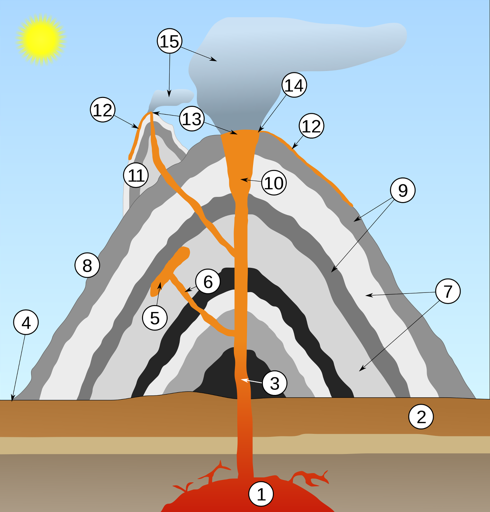

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Caption: A volcanic eruption with magma rising from the earth's interior, erupting through a vent, and spreading across the landscape, with lava flows and smoke visible against a sunny sky.


In [19]:
# Caption an image with the pruned VLM. Expect coherent text; the model will recover further with KD.
from PIL import Image
from IPython.display import display
import requests

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

preview = image.copy()
preview.thumbnail((512, 512))
display(preview)

messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": "Describe the image in one short sentence."},
]}]
inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
).to(pruned.device)
out = pruned.generate(**inputs, max_new_tokens=64, do_sample=False)
print("Caption:", processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0])

Don't worry if the caption is noticeably worse than the original VLM's output — pruning always degrades quality. The next notebook ([`02_distillation_vlm.ipynb`](02_distillation_vlm.ipynb)) recovers most of that loss via text-only knowledge distillation from the unpruned teacher.

In [20]:
import gc, torch
del pruned; gc.collect(); torch.cuda.empty_cache()